## End-to-End CO2/O2 Overpotential Prediction

This notebook trains and evaluates TabPFN regression models for CO2 and O2 overpotential prediction.

Workflow:
1. Load the predefined training and outer-test datasets.
2. Train the models and perform compound-level grouped cross-validation.
3. Evaluate and visualize model predictions.
4. Predict the screening dataset at 500 mA g⁻¹.

The prediction results are saved in the `predict` directory.

### CO2

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor
from utils import eval, visual, save, save_model
import numpy as np
from sklearn.model_selection import KFold
import pandas as pd
from sklearn.model_selection import GroupKFold

D:\app\miniconda\envs\mp311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the predefined training and outer-test datasets
train_data = pd.read_csv(
    "data/end_to_end_model_data/co2_train_with_structure.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_model_data/co2_test_with_structure.csv"
)


# Identify the compound column
compound_col = (
    "compound"
    if "compound" in train_data.columns
    else "compounds"
)


# Define the target column
target_col = "overpotential"


# Define feature columns
excluded_cols = [
    compound_col,
    target_col
]

feature_cols = [
    col for col in train_data.columns
    if col not in excluded_cols
]


# Prepare the training data
X_train = train_data[
    feature_cols
].astype(float)

y_train = train_data[
    target_col
].astype(float)


# Prepare the outer-test data
X_test = test_data[
    feature_cols
].astype(float)

y_test = test_data[
    target_col
].astype(float)


# Store compound names for later analysis
train_compounds = train_data[
    compound_col
].copy()

test_compounds = test_data[
    compound_col
].copy()


# Perform basic data checks
if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and test feature columns are inconsistent."
    )

if X_train.isna().any().any():
    raise ValueError(
        "Missing values found in training features."
    )

if X_test.isna().any().any():
    raise ValueError(
        "Missing values found in test features."
    )


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)
print("Number of features:", len(feature_cols))
print(
    "Unique training compounds:",
    train_compounds.nunique()
)
print(
    "Unique outer-test compounds:",
    test_compounds.nunique()
)

print(
    "Compound overlap:",
    len(
        set(train_compounds)
        & set(test_compounds)
    )
)

print("\nFeature columns:")
print(feature_cols)

Training shape: (582, 34)
Outer-test shape: (126, 34)
Number of features: 34
Unique training compounds: 103
Unique outer-test compounds: 19
Compound overlap: 0

Feature columns:
['AB_AN', 'AB_AW', 'AB_CR', 'AB_AR', 'AB_FIE', 'AB_SIE', 'AB_EA', 'AB_EN', 'AB_Nd', 'AB_Nv', 'AB_D', 'AB_EC', 'AB_TC', 'C_AN', 'C_AW', 'C_CR', 'C_AR', 'C_VR', 'C_FIE', 'C_SIE', 'C_EA', 'C_EN', 'C_Np', 'C_Nv', 'C_D', 'a_1', 'b_1', 'c_1', 'Grain_1', 'a_2', 'b_2', 'c_2', 'Grain_2', 'CurrentDensity']


In [3]:
X_train = np.asarray(
    X_train,
    dtype=np.float32
)

X_test = np.asarray(
    X_test,
    dtype=np.float32
)

y_train = np.asarray(
    y_train,
    dtype=np.float32
).reshape(-1)

y_test = np.asarray(
    y_test,
    dtype=np.float32
).reshape(-1)

In [4]:
def metrics(y_true, y_pred):
    r2 = r2_score(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    return r2, mae, rmse


def cv_score(
    X,
    y,
    groups,
    n_splits=5
):
    gkf = GroupKFold(
        n_splits=n_splits
    )

    r2s = []
    maes = []
    rmses = []

    for fold, (tr, va) in enumerate(
        gkf.split(X, y, groups),
        1
    ):
        reg = TabPFNRegressor(
            device="cuda",
            model_path=(
                "tabpfn_models/"
                "tabpfn-v3-regressor-v3_default.ckpt"
            ),
            n_estimators=8,
            softmax_temperature=0.8,
            random_state=42
        )

        reg.fit(
            X[tr],
            y[tr]
        )

        pred = reg.predict(
            X[va]
        )

        r2, mae, rmse = metrics(
            y[va],
            pred
        )

        r2s.append(r2)
        maes.append(mae)
        rmses.append(rmse)

        print(
            f"Fold {fold}: "
            f"R2={r2:.6f} | "
            f"MAE={mae:.6f} | "
            f"RMSE={rmse:.6f} | "
            f"Train compounds="
            f"{len(set(groups[tr]))} | "
            f"Valid compounds="
            f"{len(set(groups[va]))}"
        )

    return (
        (np.mean(r2s), np.std(r2s)),
        (np.mean(maes), np.std(maes)),
        (np.mean(rmses), np.std(rmses))
    )

In [5]:
regressor = TabPFNRegressor(
    device="cuda", 
    model_path="tabpfn_models/tabpfn-v3-regressor-v3_default.ckpt", 
    n_estimators=8,    
    # auto_scale_n_estimators=False,
    # fit_mode="fit_with_cache",
    softmax_temperature=0.8,
    random_state=42
)
regressor.fit(X_train, y_train)

train_pred = regressor.predict(X_train)
test_pred = regressor.predict(X_test)

tr_r2, tr_mae, tr_rmse = metrics(y_train, train_pred)
te_r2, te_mae, te_rmse = metrics(y_test, test_pred)

print("【Train】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(tr_r2, tr_mae, tr_rmse))
print("【Outer test】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(te_r2, te_mae, te_rmse))

compound_col = "compound" if "compound" in train_data.columns else "compounds"
groups_train = train_data[compound_col].astype(str).to_numpy()

print(len(X_train), len(y_train), len(groups_train))

(cv_r2, cv_r2_std), (cv_mae, cv_mae_std), (cv_rmse, cv_rmse_std) = cv_score(X_train, y_train, groups_train)

print("【Group CV-5】 R²={:.6f}±{:.6f} | MAE={:.6f}±{:.6f} | RMSE={:.6f}±{:.6f}".format(
    cv_r2, cv_r2_std, cv_mae, cv_mae_std, cv_rmse, cv_rmse_std
))

【Train】 R²=0.985373 | MAE=0.020566 | RMSE=0.049631
【Outer test】 R²=0.867769 | MAE=0.125333 | RMSE=0.157726
582 582 582
Fold 1: R2=0.703950 | MAE=0.147944 | RMSE=0.189687 | Train compounds=82 | Valid compounds=21
Fold 2: R2=0.671217 | MAE=0.161829 | RMSE=0.208164 | Train compounds=83 | Valid compounds=20
Fold 3: R2=0.753537 | MAE=0.165419 | RMSE=0.211050 | Train compounds=82 | Valid compounds=21
Fold 4: R2=0.819179 | MAE=0.129367 | RMSE=0.170541 | Train compounds=83 | Valid compounds=20
Fold 5: R2=0.836111 | MAE=0.155660 | RMSE=0.195165 | Train compounds=82 | Valid compounds=21
【Group CV-5】 R²=0.756799±0.063733 | MAE=0.152044±0.012797 | RMSE=0.194921±0.014542


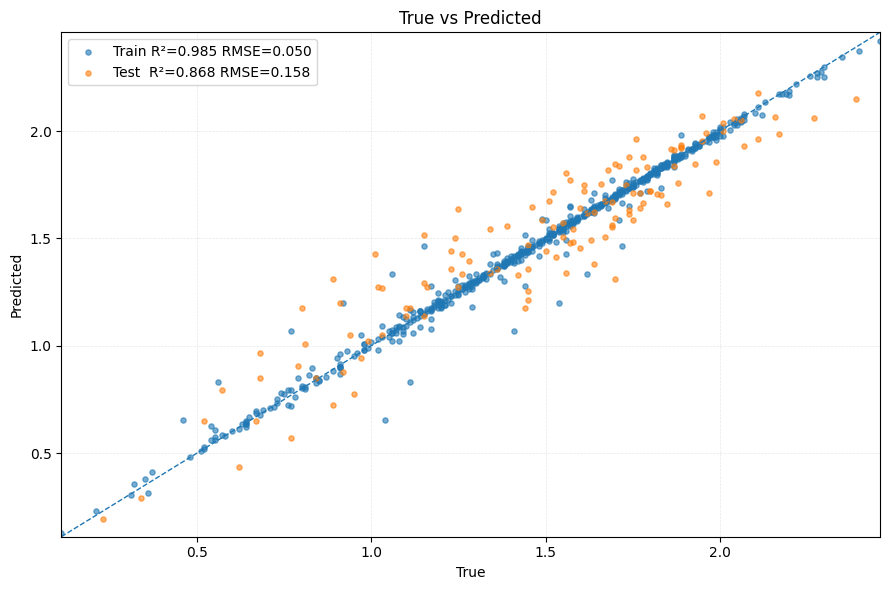

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()
p_tr = np.asarray(regressor.predict(X_train)).ravel()
p_te = np.asarray(regressor.predict(X_test)).ravel()

def r2_rmse(y, p):
    r2 = r2_score(y, p)
    rmse = np.sqrt(mean_squared_error(y, p))
    return r2, rmse

r2_tr, rmse_tr = r2_rmse(y_tr, p_tr)
r2_te, rmse_te = r2_rmse(y_te, p_te)

lo = float(min(y_tr.min(), y_te.min(), p_tr.min(), p_te.min()))
hi = float(max(y_tr.max(), y_te.max(), p_tr.max(), p_te.max()))

plt.figure(figsize=(9, 6))
plt.scatter(y_tr, p_tr, s=14, alpha=0.6, label=f"Train R²={r2_tr:.3f} RMSE={rmse_tr:.3f}")
plt.scatter(y_te, p_te, s=14, alpha=0.6, label=f"Test  R²={r2_te:.3f} RMSE={rmse_te:.3f}")
plt.plot([lo, hi], [lo, hi], '--', lw=1)  # y=x
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.legend()
plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [7]:
# Save scatter points for external plotting
from pathlib import Path


# Create a DataFrame for training points
df_train = pd.DataFrame({
    "split": "train",
    "row_id": np.arange(len(y_tr)),
    "y_true": y_tr,
    "y_pred": p_tr,
    "residual": y_tr - p_tr,
})


# Create a DataFrame for test points
df_test = pd.DataFrame({
    "split": "test",
    "row_id": np.arange(len(y_te)),
    "y_true": y_te,
    "y_pred": p_te,
    "residual": y_te - p_te,
})


# Combine training and test points
df_points = pd.concat(
    [
        df_train,
        df_test
    ],
    ignore_index=True
)


# Save the scatter-point data
out_path = Path(
    "plots/TabPFN_CO2_final.csv"
)

out_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

df_points.to_csv(
    out_path,
    index=False
)

print(
    f"Saved scatter points to: "
    f"{out_path} "
    f"(rows={len(df_points)})"
)

Saved scatter points to: plots/TabPFN_CO2_final.csv  (rows=708)


In [13]:
import os
import gc
import time

import numpy as np
import pandas as pd

from tqdm import tqdm


# Load the screening dataset
df_new = pd.read_csv(
    "data/compound_new_MCs_structure.csv"
)


# Add current density as the last feature
CURRENT_DENSITY_VAL = 500

df_new["CurrentDensity"] = (
    CURRENT_DENSITY_VAL
)

cols = [
    c for c in df_new.columns
    if c not in (
        "compound",
        "CurrentDensity"
    )
]

cols = cols + [
    "CurrentDensity"
]

df_ordered = df_new[
    ["compound"] + cols
]


# Extract compound names and prediction features
compounds = df_ordered[
    "compound"
].values

X_pred = df_ordered.drop(
    columns=["compound"]
).to_numpy(
    dtype=np.float32
)


# Define the outer batch size
OUTER_BATCH = 2000


def _as_mean_array(out):
    if isinstance(out, dict):
        for key in (
            "mean",
            "pred",
            "prediction",
            "preds"
        ):
            if key in out:
                return np.asarray(
                    out[key],
                    dtype=np.float32
                ).ravel()

        return np.asarray(
            out,
            dtype=np.float32
        ).ravel()

    return np.asarray(
        out,
        dtype=np.float32
    ).ravel()


# Use an expandable CUDA memory allocation strategy
os.environ.setdefault(
    "PYTORCH_CUDA_ALLOC_CONF",
    "expandable_segments:True"
)


# Use torch for GPU synchronization and cache clearing
try:
    import torch

    HAS_TORCH = torch.cuda.is_available()

except Exception:
    HAS_TORCH = False


def predict_with_microchunks(
    Xb,
    start_idx,
    preds,
    init_micro=512,
    min_micro=1
):
    """
    Split each outer batch into adaptive micro-batches
    to reduce the risk of CUDA out-of-memory errors.

    Parameters
    ----------
    Xb : array-like
        Data in the current outer batch.

    start_idx : int
        Starting index of the current outer batch
        in the complete prediction array.

    preds : numpy.ndarray
        Complete prediction array.
    """

    n = len(Xb)
    done = 0
    micro = init_micro

    while done < n:
        end = min(
            done + micro,
            n
        )

        try:
            out = regressor.predict(
                Xb[done:end],
                output_type="main"
            )

            mu = _as_mean_array(
                out
            )

            preds[
                start_idx + done:
                start_idx + end
            ] = mu[
                :(end - done)
            ]

            done = end


            # Release temporary objects and clear GPU memory
            if HAS_TORCH:
                try:
                    torch.cuda.synchronize()
                    torch.cuda.empty_cache()

                except Exception:
                    pass

            del out, mu

            gc.collect()
            time.sleep(0.002)

        except RuntimeError as e:
            msg = str(e).lower()

            if (
                "out of memory" in msg
                or "cuda" in msg
            ) and micro > min_micro:

                micro = max(
                    min_micro,
                    micro // 2
                )

                print(
                    f"[OOM] "
                    f"Inner micro-batch size: {micro}"
                )

                if HAS_TORCH:
                    try:
                        torch.cuda.synchronize()
                        torch.cuda.empty_cache()

                    except Exception:
                        pass

                gc.collect()
                time.sleep(0.02)

            else:
                # Raise the error if a single sample cannot be processed
                raise


# Allocate the prediction array
n = len(X_pred)

preds = np.empty(
    n,
    dtype=np.float32
)

print(
    f"[Info] pool size={n}, "
    f"n_features={X_pred.shape[1]}, "
    f"outer_batch={OUTER_BATCH}"
)


# Predict the screening dataset in batches
pbar = tqdm(
    total=n,
    desc="Predicting CO2 overpotential",
    unit="row"
)

for i in range(
    0,
    n,
    OUTER_BATCH
):
    end = min(
        i + OUTER_BATCH,
        n
    )

    Xb = X_pred[i:end]

    # Apply adaptive micro-batching within each outer batch
    predict_with_microchunks(
        Xb,
        start_idx=i,
        preds=preds,
        init_micro=512,
        min_micro=1
    )

    pbar.update(
        end - i
    )


    # Clear memory after each outer batch
    if HAS_TORCH:
        try:
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

        except Exception:
            pass

    del Xb
    gc.collect()

pbar.close()


# Save screening predictions
os.makedirs(
    "predict",
    exist_ok=True
)

pd.DataFrame({
    "compound": compounds,
    "predicted_mean": preds
}).to_csv(
    "predict/tabpfn_predict_CO2_final_500.csv",
    index=False
)

print(
    "Saved "
    "'predict/tabpfn_predict_CO2_final_500.csv'"
)

[Info] pool size=25012, n_features=34, outer_batch=2000


predict mean (TabPFN): 100%|██████████| 25012/25012 [00:34<00:00, 729.82row/s]

✅ saved 'predict/tabpfn_predict_CO2_final_500.csv'


### O2

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor
from utils import eval, visual, save, save_model
import numpy as np
from sklearn.model_selection import KFold
import pandas as pd
from sklearn.model_selection import GroupKFold

In [2]:
# Load the predefined training and outer-test datasets
train_data = pd.read_csv(
    "data/end_to_end_model_data/o2_train_with_structure.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_model_data/o2_test_with_structure.csv"
)


# Identify the compound column
compound_col = (
    "compound"
    if "compound" in train_data.columns
    else "compounds"
)


# Define the target column
target_col = "overpotential"


# Define feature columns
excluded_cols = [
    compound_col,
    target_col
]

feature_cols = [
    col for col in train_data.columns
    if col not in excluded_cols
]


# Prepare training data
X_train = train_data[feature_cols].astype(float)
y_train = train_data[target_col].astype(float)


# Prepare outer-test data
X_test = test_data[feature_cols].astype(float)
y_test = test_data[target_col].astype(float)


# Save compound names for later analysis
train_compounds = train_data[compound_col].copy()
test_compounds = test_data[compound_col].copy()


# Basic checks
if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and test feature columns are inconsistent."
    )

if X_train.isna().any().any():
    raise ValueError(
        "Missing values found in training features."
    )

if X_test.isna().any().any():
    raise ValueError(
        "Missing values found in test features."
    )


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)
print("Number of features:", len(feature_cols))
print("Unique training compounds:", train_compounds.nunique())
print("Unique outer-test compounds:", test_compounds.nunique())
print(
    "Compound overlap:",
    len(
        set(train_compounds)
        & set(test_compounds)
    )
)

print("\nFeature columns:")
print(feature_cols)

Training shape: (334, 34)
Outer-test shape: (115, 34)
Number of features: 34
Unique training compounds: 75
Unique outer-test compounds: 20
Compound overlap: 0

Feature columns:
['AB_AN', 'AB_AW', 'AB_CR', 'AB_AR', 'AB_FIE', 'AB_SIE', 'AB_EA', 'AB_EN', 'AB_Nd', 'AB_Nv', 'AB_D', 'AB_EC', 'AB_TC', 'C_AN', 'C_AW', 'C_CR', 'C_AR', 'C_VR', 'C_FIE', 'C_SIE', 'C_EA', 'C_EN', 'C_Np', 'C_Nv', 'C_D', 'a_1', 'b_1', 'c_1', 'Grain_1', 'a_2', 'b_2', 'c_2', 'Grain_2', 'CurrentDensity']


In [3]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test,  dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
y_test  = np.asarray(y_test,  dtype=np.float32).reshape(-1)

In [4]:
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, mae, rmse

def cv_score(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    r2s, maes, rmses = [], [], []

    for fold, (tr, va) in enumerate(gkf.split(X, y, groups), 1):
        reg = TabPFNRegressor(device="cuda", model_path="tabpfn_models/tabpfn-v3-regressor-v3_default.ckpt", n_estimators=8, random_state=42)
        reg.fit(X[tr], y[tr])
        pred = reg.predict(X[va])

        r2, mae, rmse = metrics(y[va], pred)
        r2s.append(r2); maes.append(mae); rmses.append(rmse)

        print(f"Fold {fold}: R2={r2:.6f} | MAE={mae:.6f} | RMSE={rmse:.6f} | Train compounds={len(set(groups[tr]))} | Valid compounds={len(set(groups[va]))}")

    return (np.mean(r2s), np.std(r2s)), (np.mean(maes), np.std(maes)), (np.mean(rmses), np.std(rmses))

In [5]:
regressor = TabPFNRegressor(
    device="cuda", 
    model_path="tabpfn_models/tabpfn-v3-regressor-v3_default.ckpt", 
    n_estimators=16, 
    softmax_temperature = 1.2, 
    random_state=2027)
regressor.fit(X_train, y_train)

train_pred = regressor.predict(X_train)
test_pred = regressor.predict(X_test)

tr_r2, tr_mae, tr_rmse = metrics(y_train, train_pred)
te_r2, te_mae, te_rmse = metrics(y_test, test_pred)

print("【Train】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(tr_r2, tr_mae, tr_rmse))
print("【Outer test】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(te_r2, te_mae, te_rmse))

compound_col = "compound" if "compound" in train_data.columns else "compounds"
groups_train = train_data[compound_col].astype(str).to_numpy()

print(len(X_train), len(y_train), len(groups_train))

(cv_r2, cv_r2_std), (cv_mae, cv_mae_std), (cv_rmse, cv_rmse_std) = cv_score(X_train, y_train, groups_train)

print("【Group CV-5】 R²={:.6f}±{:.6f} | MAE={:.6f}±{:.6f} | RMSE={:.6f}±{:.6f}".format(
    cv_r2, cv_r2_std, cv_mae, cv_mae_std, cv_rmse, cv_rmse_std
))

【Train】 R²=0.991288 | MAE=0.021389 | RMSE=0.036299
【Outer test】 R²=0.889716 | MAE=0.099020 | RMSE=0.128762
334 334 334
Fold 1: R2=0.870626 | MAE=0.085845 | RMSE=0.114246 | Train compounds=59 | Valid compounds=16
Fold 2: R2=0.772163 | MAE=0.152543 | RMSE=0.211990 | Train compounds=62 | Valid compounds=13
Fold 3: R2=0.603606 | MAE=0.087115 | RMSE=0.161999 | Train compounds=60 | Valid compounds=15
Fold 4: R2=0.844702 | MAE=0.119088 | RMSE=0.173802 | Train compounds=60 | Valid compounds=15
Fold 5: R2=0.841664 | MAE=0.122029 | RMSE=0.164004 | Train compounds=59 | Valid compounds=16
【Group CV-5】 R²=0.786552±0.097122 | MAE=0.113324±0.024856 | RMSE=0.165209±0.031213


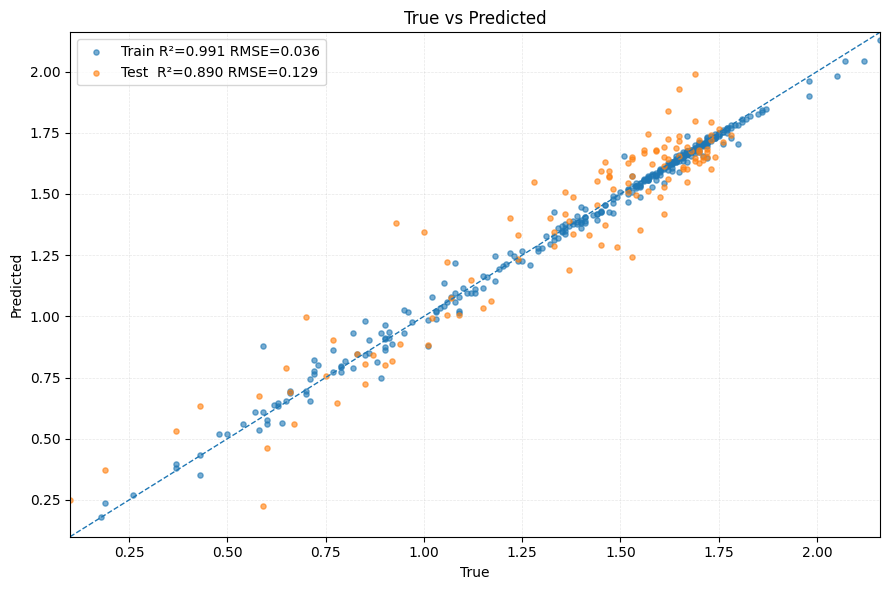

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()
p_tr = np.asarray(regressor.predict(X_train)).ravel()
p_te = np.asarray(regressor.predict(X_test)).ravel()

def r2_rmse(y, p):
    r2 = r2_score(y, p)
    rmse = np.sqrt(mean_squared_error(y, p))
    return r2, rmse

r2_tr, rmse_tr = r2_rmse(y_tr, p_tr)
r2_te, rmse_te = r2_rmse(y_te, p_te)

lo = float(min(y_tr.min(), y_te.min(), p_tr.min(), p_te.min()))
hi = float(max(y_tr.max(), y_te.max(), p_tr.max(), p_te.max()))

plt.figure(figsize=(9, 6))
plt.scatter(y_tr, p_tr, s=14, alpha=0.6, label=f"Train R²={r2_tr:.3f} RMSE={rmse_tr:.3f}")
plt.scatter(y_te, p_te, s=14, alpha=0.6, label=f"Test  R²={r2_te:.3f} RMSE={rmse_te:.3f}")
plt.plot([lo, hi], [lo, hi], '--', lw=1)  # y=x
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.legend()
plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [7]:
# Save scatter points for external plotting
from pathlib import Path


# Create a DataFrame for training points
df_train = pd.DataFrame({
    "split": "train",
    "row_id": np.arange(len(y_tr)),
    "y_true": y_tr,
    "y_pred": p_tr,
    "residual": y_tr - p_tr,
})


# Create a DataFrame for test points
df_test = pd.DataFrame({
    "split": "test",
    "row_id": np.arange(len(y_te)),
    "y_true": y_te,
    "y_pred": p_te,
    "residual": y_te - p_te,
})


# Combine training and test points
df_points = pd.concat(
    [
        df_train,
        df_test
    ],
    ignore_index=True
)


# Save the scatter-point data
out_path = Path(
    "plots/TabPFN_O2_final.csv"
)

out_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

df_points.to_csv(
    out_path,
    index=False
)

print(
    f"Saved scatter points to: "
    f"{out_path} "
    f"(rows={len(df_points)})"
)

Saved scatter points to: plots/TabPFN_O2_final.csv  (rows=449)


In [13]:
import os
import gc
import time

import numpy as np
import pandas as pd

from tqdm import tqdm


# Load the screening dataset
df_new = pd.read_csv(
    "data/compound_new_MCs_structure.csv"
)


# Add current density as the last feature
CURRENT_DENSITY_VAL = 500

df_new["CurrentDensity"] = (
    CURRENT_DENSITY_VAL
)

cols = [
    c for c in df_new.columns
    if c not in (
        "compound",
        "CurrentDensity"
    )
]

cols = cols + [
    "CurrentDensity"
]

df_ordered = df_new[
    ["compound"] + cols
]


# Extract compound names and prediction features
compounds = df_ordered[
    "compound"
].values

X_pred = df_ordered.drop(
    columns=["compound"]
).to_numpy(
    dtype=np.float32
)


# Define the outer batch size
OUTER_BATCH = 2000


def _as_mean_array(out):
    if isinstance(out, dict):
        for key in (
            "mean",
            "pred",
            "prediction",
            "preds"
        ):
            if key in out:
                return np.asarray(
                    out[key],
                    dtype=np.float32
                ).ravel()

        return np.asarray(
            out,
            dtype=np.float32
        ).ravel()

    return np.asarray(
        out,
        dtype=np.float32
    ).ravel()


# Use an expandable CUDA memory allocation strategy
os.environ.setdefault(
    "PYTORCH_CUDA_ALLOC_CONF",
    "expandable_segments:True"
)


# Use torch for GPU synchronization and cache clearing
try:
    import torch

    HAS_TORCH = torch.cuda.is_available()

except Exception:
    HAS_TORCH = False


def predict_with_microchunks(
    Xb,
    start_idx,
    preds,
    init_micro=512,
    min_micro=1
):
    """
    Split each outer batch into adaptive micro-batches
    to reduce the risk of CUDA out-of-memory errors.

    Parameters
    ----------
    Xb : array-like
        Data in the current outer batch.

    start_idx : int
        Starting index of the current outer batch
        in the complete prediction array.

    preds : numpy.ndarray
        Complete prediction array.
    """

    n = len(Xb)
    done = 0
    micro = init_micro

    while done < n:
        end = min(
            done + micro,
            n
        )

        try:
            out = regressor.predict(
                Xb[done:end],
                output_type="main"
            )

            mu = _as_mean_array(
                out
            )

            preds[
                start_idx + done:
                start_idx + end
            ] = mu[
                :(end - done)
            ]

            done = end


            # Release temporary objects and clear GPU memory
            if HAS_TORCH:
                try:
                    torch.cuda.synchronize()
                    torch.cuda.empty_cache()

                except Exception:
                    pass

            del out, mu

            gc.collect()
            time.sleep(0.002)

        except RuntimeError as e:
            msg = str(e).lower()

            if (
                "out of memory" in msg
                or "cuda" in msg
            ) and micro > min_micro:

                micro = max(
                    min_micro,
                    micro // 2
                )

                print(
                    f"[OOM] "
                    f"Inner micro-batch size: {micro}"
                )

                if HAS_TORCH:
                    try:
                        torch.cuda.synchronize()
                        torch.cuda.empty_cache()

                    except Exception:
                        pass

                gc.collect()
                time.sleep(0.02)

            else:
                # Raise the error if a single sample cannot be processed
                raise


# Allocate the prediction array
n = len(X_pred)

preds = np.empty(
    n,
    dtype=np.float32
)

print(
    f"[Info] pool size={n}, "
    f"n_features={X_pred.shape[1]}, "
    f"outer_batch={OUTER_BATCH}"
)


# Predict the screening dataset in batches
pbar = tqdm(
    total=n,
    desc="Predicting O2 overpotential",
    unit="row"
)

for i in range(
    0,
    n,
    OUTER_BATCH
):
    end = min(
        i + OUTER_BATCH,
        n
    )

    Xb = X_pred[i:end]

    # Apply adaptive micro-batching within each outer batch
    predict_with_microchunks(
        Xb,
        start_idx=i,
        preds=preds,
        init_micro=512,
        min_micro=1
    )

    pbar.update(
        end - i
    )


    # Clear memory after each outer batch
    if HAS_TORCH:
        try:
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

        except Exception:
            pass

    del Xb
    gc.collect()

pbar.close()


# Save screening predictions
os.makedirs(
    "predict",
    exist_ok=True
)

pd.DataFrame({
    "compound": compounds,
    "predicted_mean": preds
}).to_csv(
    "predict/tabpfn_predict_O2_final_500.csv",
    index=False
)

print(
    "Saved "
    "'predict/tabpfn_predict_O2_final_500.csv'"
)

[Info] pool size=25012, n_features=34, outer_batch=2000


predict mean (TabPFN): 100%|██████████| 25012/25012 [00:57<00:00, 432.75row/s]

✅ saved 'predict/tabpfn_predict_O2_final_500.csv'
